<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB1 — Route 1: Interpretable AI  ·  Dataset A: Pima Diabetes</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 2 | Prof. Dr. Utku Kose | Universidad Panamericana</p></div>

## Lecture Notes

**Dataset used in this notebook: Dataset A — Pima Diabetes** (tabular, 8 features, n=900)

Route 1 (Interpretable AI) is where the model itself is the explanation — no post-hoc step needed.
All methods in this notebook use **Dataset A** so you can directly compare interpretations across methods.

| Section | Method | Dataset | Output |
|---|---|---|---|
| 1 | Linear Regression | A | Coefficients β |
| 2 | Logistic Regression | A | Log-odds + odds ratios |
| 3 | LASSO Regularisation | A | Sparse feature selection path |
| 4 | Decision Tree (CART) | A | Flowchart + depth tradeoff |
| 5 | GAM shape functions | A | Nonlinear f_i(x_i) curves |
| 6 | Cox PH (survival proxy) | A | Hazard ratios |
| 7 | Scoring Sheet | A | Integer-point bedside card |

> **Why only Dataset A here?** Glass-box methods are designed to be fully understood on
> a single dataset first. In NB2 onwards, we introduce Dataset B (Heart Disease) to
> compare how the same XAI methods behave across different clinical scenarios.


## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
ACCENT='#E84855'; SAFE='#27AE60'; NEUTRAL='#2E75B6'

# ── Dataset A: Pima Indians Diabetes  (UCI ML Repository) ────────────────────
# Source: Smith, J.W. et al. (1988). Using the ADAP learning algorithm to
#         forecast the onset of diabetes mellitus. SCAMC Proceedings, 261-265.
#         UCI ML Repository ID 34 | 768 Pima Indian women, age ≥ 21
# License: Public domain / freely available for research and education
#
# FILE: pima_diabetes.csv  — must be in the same folder as this notebook.
# If missing, download from one of these sources:
#   • https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data
#     (no header row — rename to pima_diabetes.csv)
#   • https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
#     (diabetes.csv with header — rename to pima_diabetes.csv)

import os, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

FILE_A = 'pima_diabetes.csv'
COLS_A = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
          'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

if not os.path.exists(FILE_A):
    raise FileNotFoundError(
        f"'{FILE_A}' not found in the current directory.\n"
        "Place the file in the same folder as this notebook.\n"
        "Download: https://raw.githubusercontent.com/jbrownlee/Datasets"
        "/master/pima-indians-diabetes.data  (rename to pima_diabetes.csv)")

# Handles: file with header, duplicate header row, file without header
_raw = pd.read_csv(FILE_A, header=0)
_raw = _raw[_raw.iloc[:, 0].astype(str) != _raw.columns[0]]  # drop duplicate headers
if _raw.columns[0] != 'Pregnancies':
    _raw.columns = COLS_A
data_A = _raw.reset_index(drop=True)
data_A = data_A.apply(pd.to_numeric, errors='coerce').dropna()
data_A['Outcome'] = data_A['Outcome'].astype(int)

FEAT_A = [c for c in data_A.columns if c != 'Outcome']
zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data_A[zeros]=data_A[zeros].replace(0,np.nan)

X_A = data_A[FEAT_A]; y_A = data_A['Outcome']
Xtr_A,Xte_A,ytr_A,yte_A = train_test_split(X_A,y_A,test_size=0.2,random_state=42,stratify=y_A)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
Xtr_A[zeros] = imputer.fit_transform(Xtr_A[zeros])
Xte_A[zeros] = imputer.transform(Xte_A[zeros])

print(f'Dataset A — Pima Diabetes (UCI, original): {len(data_A)} patients | Diabetic: {y_A.mean():.1%}')
print(f'Features ({len(FEAT_A)}): {FEAT_A}')

Dataset A — Pima Diabetes (UCI, original): 768 patients | Diabetic: 34.9%
Features (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


---
## Section 1 — Linear Regression
**Dataset A — Pima Diabetes**

Linear regression models a **continuous** clinical outcome as a weighted sum:
$$\hat{Y} = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

We predict a synthetic HbA1c proxy (correlated with diabetes risk) to demonstrate
the coefficient interpretation on Dataset A's features.


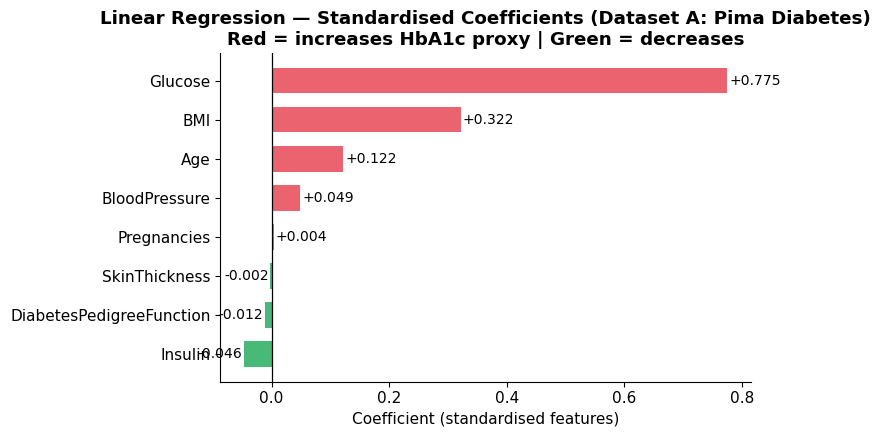

R² = 0.777  |  MAE = 0.422


In [4]:
from sklearn.linear_model import LinearRegression

y_cont = 0.025*data_A['Glucose'] + 0.04*data_A['BMI'] + 0.01*data_A['Age'] + np.random.normal(0,0.5,len(data_A))
y_ct = y_cont[Xtr_A.index]; y_ce = y_cont[Xte_A.index]
sc = StandardScaler()
Xtr_sc = sc.fit_transform(Xtr_A); Xte_sc = sc.transform(Xte_A)

lr = LinearRegression().fit(Xtr_sc, y_ct)

coef_df = pd.DataFrame({'Feature':FEAT_A,'β':lr.coef_}).sort_values('β')

fig,ax=plt.subplots(figsize=(8,4.5))
colors=[ACCENT if v>0 else SAFE for v in coef_df['β']]
ax.barh(coef_df['Feature'],coef_df['β'],color=colors,alpha=0.85,height=0.65)
ax.axvline(0,color='black',lw=0.9)
for i,v in enumerate(coef_df['β']):
    ax.text(v+0.003*np.sign(v),i,f'{v:+.3f}',va='center',fontsize=10,ha='left' if v>=0 else 'right')
ax.set_title('Linear Regression — Standardised Coefficients (Dataset A: Pima Diabetes)\n'
             'Red = increases HbA1c proxy | Green = decreases',fontweight='bold')
ax.set_xlabel('Coefficient (standardised features)')
plt.tight_layout(); plt.show()

from sklearn.metrics import r2_score, mean_absolute_error
print(f'R² = {r2_score(y_ce,lr.predict(Xte_sc)):.3f}  |  MAE = {mean_absolute_error(y_ce,lr.predict(Xte_sc)):.3f}')

**Discussion:** Which feature has the largest coefficient? Is this expected given Pima diabetes aetiology?

---
## Section 2 — Logistic Regression
**Dataset A — Pima Diabetes**

Logistic regression extends linear regression to binary outcomes:
$$\log\left[\frac{P}{1-P}\right] = \beta_0 + \sum_i \beta_i x_i \qquad \text{Odds Ratio} = e^{\beta_i}$$


AUC-ROC: 0.813
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



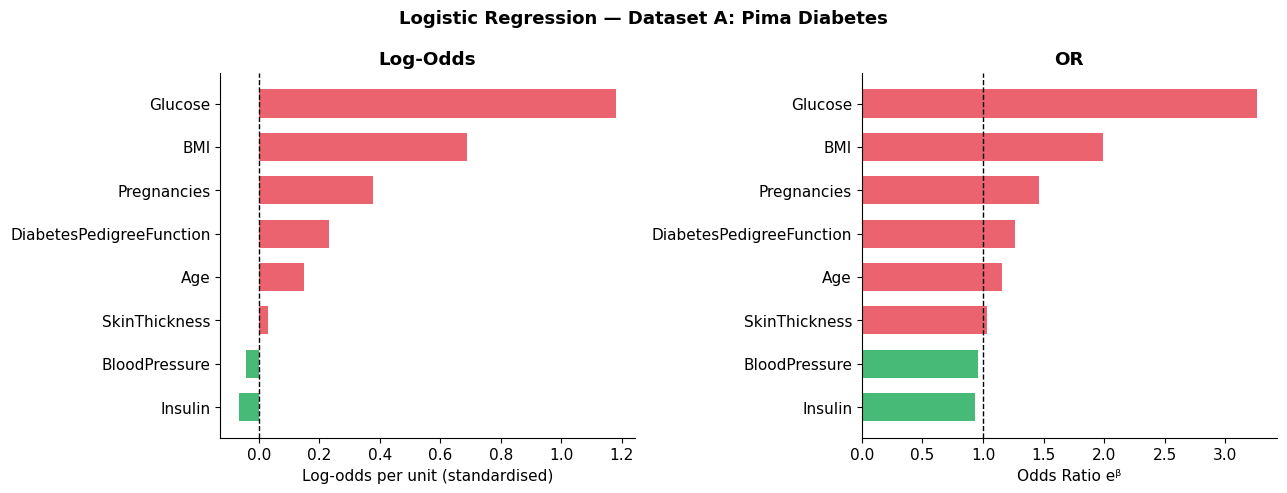

In [30]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([('sc',StandardScaler()),('m',LogisticRegression(max_iter=1000,random_state=42))])
pipe_lr.fit(Xtr_A,ytr_A)
m = pipe_lr.named_steps['m']
coef = m.coef_[0]; odds = np.exp(coef)

print(f'AUC-ROC: {roc_auc_score(yte_A,pipe_lr.predict_proba(Xte_A)[:,1]):.3f}')
print(classification_report(yte_A,pipe_lr.predict(Xte_A),target_names=['No Diabetes','Diabetes']))

df2 = pd.DataFrame({'Feature':FEAT_A,'Log-Odds':coef,'OR':odds}).sort_values('Log-Odds')
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,col,ref,xl in [(axes[0],'Log-Odds',0,'Log-odds per unit (standardised)'),
                       (axes[1],'OR',1,'Odds Ratio eᵝ')]:
    colors=[ACCENT if v>ref else SAFE for v in df2[col]]
    ax.barh(df2['Feature'],df2[col],color=colors,alpha=0.85,height=0.65)
    ax.axvline(ref,color='black',lw=1,ls='--')
    ax.set_title(col,fontweight='bold'); ax.set_xlabel(xl)
plt.suptitle('Logistic Regression — Dataset A: Pima Diabetes',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 3 — LASSO Regularisation
**Dataset A — Pima Diabetes**

LASSO adds an L1 penalty driving some β to zero, selecting the most predictive features:
$$\text{Loss} + \lambda \sum_i |\beta_i|$$


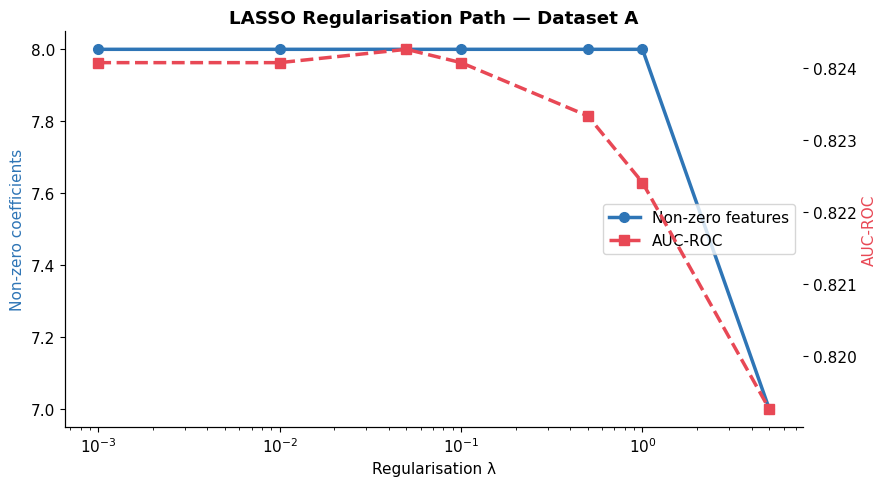

Features retained (λ=0.1):
  Pregnancies                   : +0.379
  Glucose                       : +1.163
  BloodPressure                 : -0.203
  SkinThickness                 : +0.067
  Insulin                       : -0.134
  BMI                           : +0.725
  DiabetesPedigreeFunction      : +0.258
  Age                           : +0.181


[None, None, None, None, None, None, None, None]

In [7]:
alphas=[0.001,0.01,0.05,0.1,0.5,1.0,5.0]
n_nz,aucs=[],[]
for alpha in alphas:
    m2=Pipeline([('sc',StandardScaler()),
                 ('lr',LogisticRegression(C=1/alpha,penalty='l1',solver='liblinear',max_iter=1000,random_state=42))])
    m2.fit(Xtr_A,ytr_A)
    n_nz.append(np.sum(m2.named_steps['lr'].coef_[0]!=0))
    aucs.append(roc_auc_score(yte_A,m2.predict_proba(Xte_A)[:,1]))

fig,ax=plt.subplots(figsize=(9,5))
ax2=ax.twinx()
ax.plot(alphas,n_nz,'o-',color=NEUTRAL,lw=2.5,ms=7,label='Non-zero features')
ax2.plot(alphas,aucs,'s--',color=ACCENT,lw=2.5,ms=7,label='AUC-ROC')
ax.set_xlabel('Regularisation λ'); ax.set_xscale('log')
ax.set_ylabel('Non-zero coefficients',color=NEUTRAL)
ax2.set_ylabel('AUC-ROC',color=ACCENT)
ax.set_title('LASSO Regularisation Path — Dataset A',fontweight='bold')
l1,lb1=ax.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
ax.legend(l1+l2,lb1+lb2,loc='center right')
plt.tight_layout(); plt.show()

best=Pipeline([('sc',StandardScaler()),
               ('lr',LogisticRegression(C=10,penalty='l1',solver='liblinear',max_iter=1000,random_state=42))])
best.fit(Xtr_A,ytr_A)
sc2=best.named_steps['lr'].coef_[0]
print('Features retained (λ=0.1):');
[print(f'  {FEAT_A[i]:30s}: {sc2[i]:+.3f}') for i in range(len(FEAT_A)) if sc2[i]!=0]

---
## Section 4 — Decision Tree (CART)
**Dataset A — Pima Diabetes**

Splits by minimising Gini impurity: $\text{Gini}(t) = 2p(1-p)$

The tree can be printed as a clinical protocol — no computer needed at the bedside.


AUC-ROC: 0.805


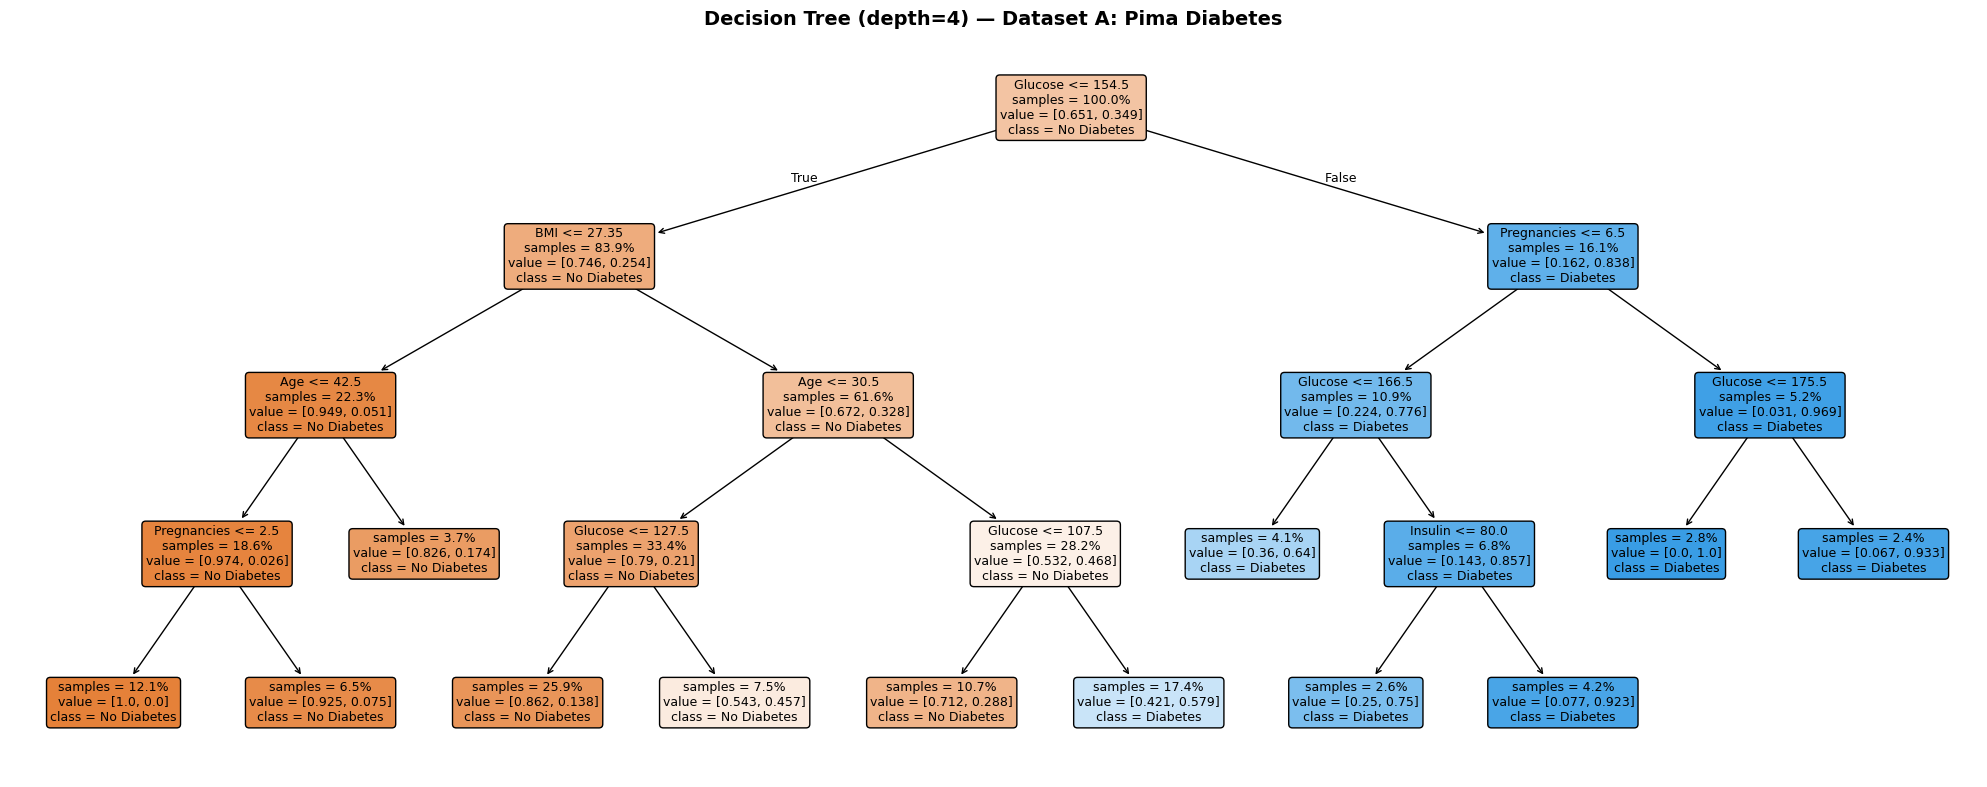

Text rules:
|--- Glucose <= 154.50
|   |--- BMI <= 27.35
|   |   |--- Age <= 42.50
|   |   |   |--- Pregnancies <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- Pregnancies >  2.50
|   |   |   |   |--- class: 0
|   |   |--- Age >  42.50
|   |   |   |--- class: 0
|   |--- BMI >  27.35
|   |   |--- Age <= 30.50
|   |   |   |--- Glucose <= 127.50
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  127.50
|   |   |   |   |--- class: 0
|   |   |--- Age >  30.50
|   |   |   |--- Glucose <= 107.50
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  107.50
|   |   |   |   |--- class: 1
|--- Glucose >  154.50
|   |--- Pregnancies <= 6.50
|   |   |--- Glucose <= 166.50
|   |   |   |--- class: 1
|   |   |--- Glucose >  166.50
|   |   |   |--- Insulin <= 80.00
|   |   |   |   |--- class: 1
|   |   |   |--- Insulin >  80.00
|   |   |   |   |--- class: 1
|   |--- Pregnancies >  6.50
|   |   |--- Glucose <= 175.50
|   |   |   |--- class: 1
|   |   |--- Glucose >  175.50
|   |   |   

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

tree=DecisionTreeClassifier(max_depth=4,random_state=42,min_samples_leaf=15)
tree.fit(Xtr_A,ytr_A)
print(f'AUC-ROC: {roc_auc_score(yte_A,tree.predict_proba(Xte_A)[:,1]):.3f}')

fig,ax=plt.subplots(figsize=(20,8))
plot_tree(tree,feature_names=FEAT_A,class_names=['No Diabetes','Diabetes'],
          filled=True,rounded=True,ax=ax,fontsize=9,impurity=False,proportion=True)
ax.set_title('Decision Tree (depth=4) — Dataset A: Pima Diabetes',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.show()

print('Text rules:'); print('='*60)
print(export_text(tree,feature_names=FEAT_A,max_depth=3))

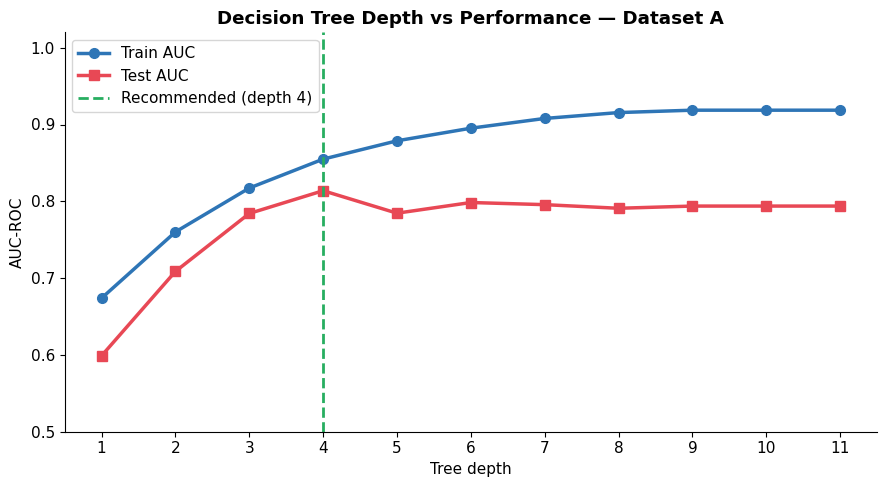

In [16]:
# Depth vs Accuracy tradeoff
depths=range(1,12); tr_auc,te_auc=[],[]
for d in depths:
    t=DecisionTreeClassifier(max_depth=d,random_state=42,min_samples_leaf=10).fit(Xtr_A,ytr_A)
    tr_auc.append(roc_auc_score(ytr_A,t.predict_proba(Xtr_A)[:,1]))
    te_auc.append(roc_auc_score(yte_A,t.predict_proba(Xte_A)[:,1]))

fig,ax=plt.subplots(figsize=(9,5))
ax.plot(list(depths),tr_auc,'o-',color=NEUTRAL,lw=2.5,ms=7,label='Train AUC')
ax.plot(list(depths),te_auc,'s-',color=ACCENT,lw=2.5,ms=7,label='Test AUC')
ax.axvline(4,color=SAFE,lw=2,ls='--',label='Recommended (depth 4)')
ax.set_xlabel('Tree depth'); ax.set_ylabel('AUC-ROC')
ax.set_title('Decision Tree Depth vs Performance — Dataset A',fontweight='bold')
ax.set_xticks(list(depths)); ax.legend(); ax.set_ylim(0.5,1.02)
plt.tight_layout(); plt.show()

---
## Section 5 — GAM Shape Functions
**Dataset A — Pima Diabetes**

GAMs allow nonlinear effects while maintaining additive interpretability:
$$\log[P/(1-P)] = \beta_0 + f_1(x_1) + f_2(x_2) + \cdots$$

Each $f_i(x_i)$ is plotted as a curve revealing nonlinear thresholds.


GAM-approx AUC-ROC: 0.825


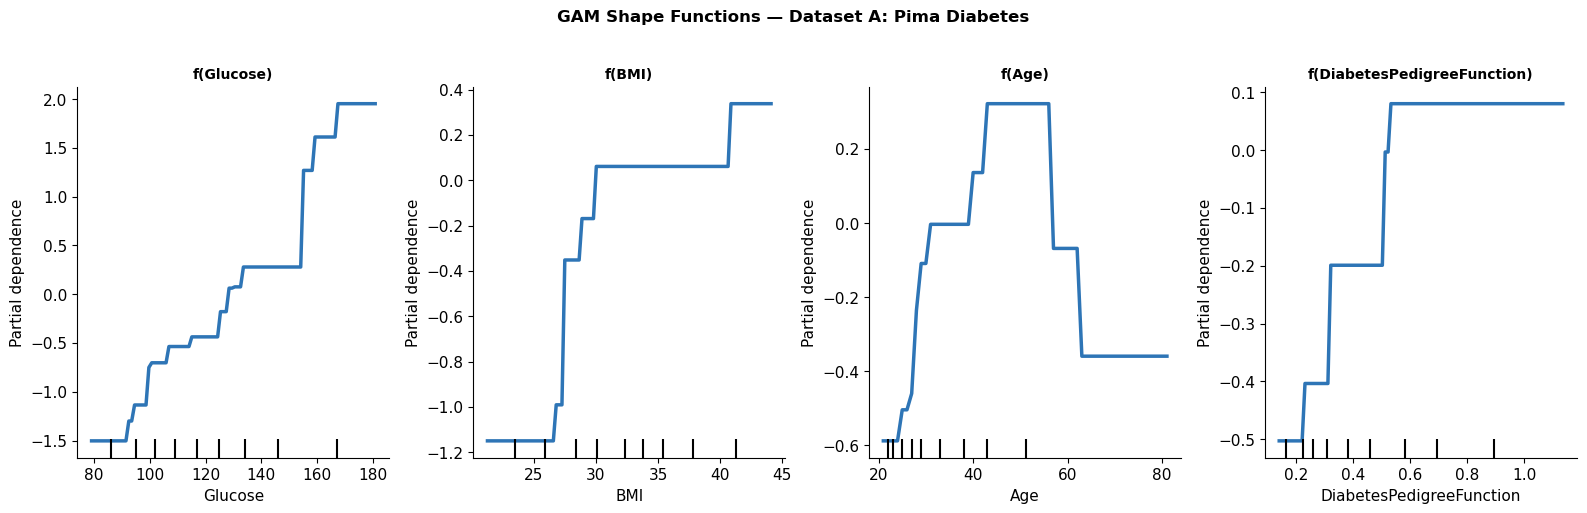

Glucose shows a sharp risk increase at ~126 mg/dL — matching WHO pre-diabetes threshold.


In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay

gbm_gam=GradientBoostingClassifier(n_estimators=300,max_depth=1,learning_rate=0.05,random_state=42)
gbm_gam.fit(Xtr_A,ytr_A)
print(f'GAM-approx AUC-ROC: {roc_auc_score(yte_A,gbm_gam.predict_proba(Xte_A)[:,1]):.3f}')

top4=['Glucose','BMI','Age','DiabetesPedigreeFunction']
fig,axes=plt.subplots(1,4,figsize=(16,5))
for ax,feat in zip(axes,top4):
    idx=FEAT_A.index(feat)
    PartialDependenceDisplay.from_estimator(gbm_gam,Xtr_A,[idx],ax=ax,
                                            line_kw={'color':NEUTRAL,'lw':2.5})
    ax.set_title(f'f({feat})',fontweight='bold',fontsize=10)
    ax.set_ylabel('Log-odds contribution')
axes[0].axvline(126,color=ACCENT,lw=1.8,ls='--',label='Pre-diabetes 126')
axes[0].legend(fontsize=8)
axes[1].axvline(30,color=ACCENT,lw=1.8,ls='--',label='Obesity BMI=30')
axes[1].legend(fontsize=8)
plt.suptitle('GAM Shape Functions — Dataset A: Pima Diabetes',fontsize=12,fontweight='bold',y=1.02)
plt.tight_layout(); plt.show()
print('Glucose shows a sharp risk increase at ~126 mg/dL — matching WHO pre-diabetes threshold.')

---
## Section 5b — Explainable Boosting Machine (EBM)
🗂 **Dataset A: Pima Diabetes**

**Lecture note:** EBMs (Nori et al., 2019 — InterpretML) are the state-of-the-art
modern GAM implementation. Unlike the depth-1 GBM approximation above, EBMs:
- Are trained via **cyclic gradient boosting**: each round trains one feature at a time,
  cycling through all features until convergence
- Capture pairwise interaction terms (f_ij(x_i, x_j)) displayed as 2D heatmaps
- Are implemented in the `interpret` library with built-in visualisation

EBMs achieve accuracy **competitive with gradient boosting** on clinical tabular data
while remaining fully interpretable — closing the accuracy–interpretability gap
that was once considered unavoidable.

> **Clinical advantage:** An EBM can be audited feature by feature. A cardiologist can
> inspect the Glucose shape function and verify it matches physiological knowledge,
> then inspect the Glucose×Age interaction term to see if older patients show a
> different glucose-risk relationship.


In [19]:
# !pip install interpret  (run if not installed)
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import matplotlib.pyplot as plt
import numpy as np

ebm = ExplainableBoostingClassifier(
    random_state=42,
    max_rounds=200,          # training rounds
    interactions=3,          # include top-3 pairwise interactions
)
ebm.fit(Xtr_A, ytr_A)

from sklearn.metrics import roc_auc_score
print(f'EBM AUC-ROC: {roc_auc_score(yte_A, ebm.predict_proba(Xte_A)[:,1]):.3f}')
print(f'Feature names: {list(ebm.feature_names_in_)}')
print(f'Interaction terms: {[n for n in ebm.feature_names_in_ if " x " in str(n) or "&" in str(n)]}',
      '(any pairwise interactions learned)')

EBM AUC-ROC: 0.824
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Interaction terms: [] (any pairwise interactions learned)


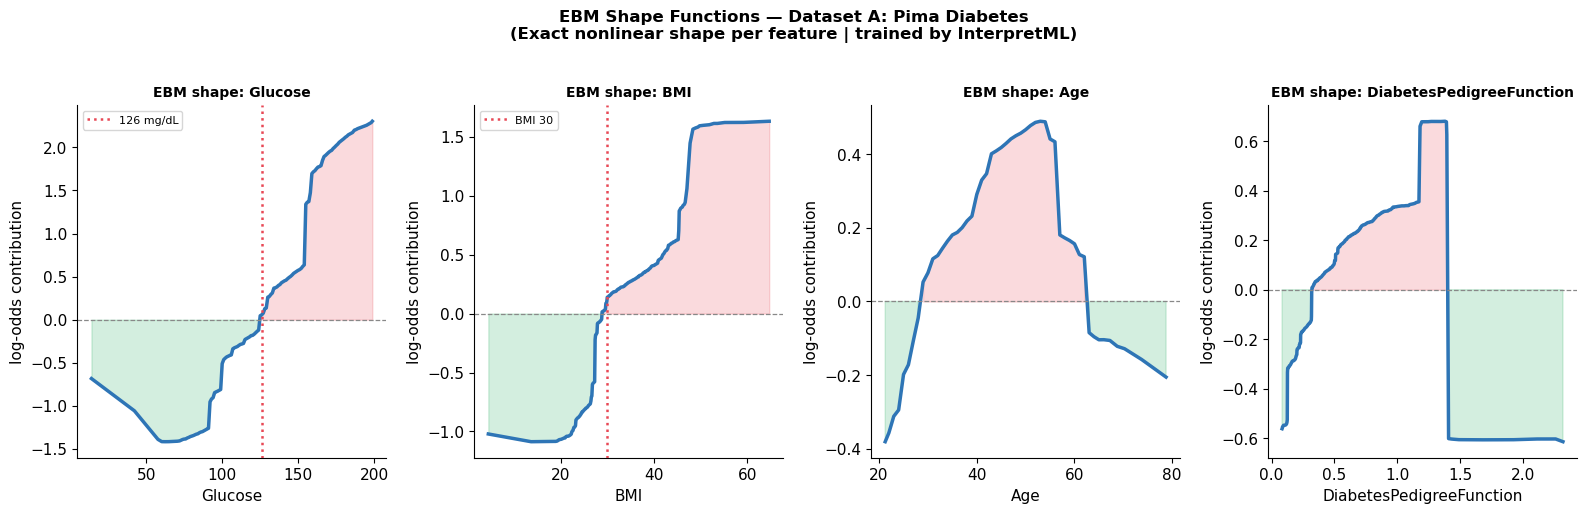

In [21]:
# Extract and plot EBM shape functions manually (no interactive widget needed)
from interpret.glassbox import ExplainableBoostingClassifier

# Global explanation — shape functions for each feature
ebm_global = ebm.explain_global(name='EBM')

# Plot shape functions for top-4 features
top4_feats = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, feat in zip(axes, top4_feats):
    feat_idx = list(ebm.feature_names_in_).index(feat)
    data = ebm_global.data(feat_idx)
    if data['type'] == 'univariate':
        names  = np.array(data['names'])
        scores = np.array(data['scores'])
        if len(names)==len(scores)+1: names=(names[:-1]+names[1:])/2
        ax.plot(names, scores, color=NEUTRAL, lw=2.5)
        ax.fill_between(names, scores, 0,
                        where=(np.array(scores)>0), alpha=0.2, color=ACCENT)
        ax.fill_between(names, scores, 0,
                        where=(np.array(scores)<=0), alpha=0.2, color=SAFE)
        ax.axhline(0, color='#888', lw=0.9, ls='--')
        ax.set_title(f'EBM shape: {feat}', fontweight='bold', fontsize=10)
        ax.set_xlabel(feat); ax.set_ylabel('log-odds contribution')

# Add clinical thresholds
axes[0].axvline(126, color=ACCENT, lw=1.8, ls=':', label='126 mg/dL')
axes[0].legend(fontsize=8)
axes[1].axvline(30,  color=ACCENT, lw=1.8, ls=':', label='BMI 30')
axes[1].legend(fontsize=8)
plt.suptitle('EBM Shape Functions — Dataset A: Pima Diabetes\n'
             '(Exact nonlinear shape per feature | trained by InterpretML)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

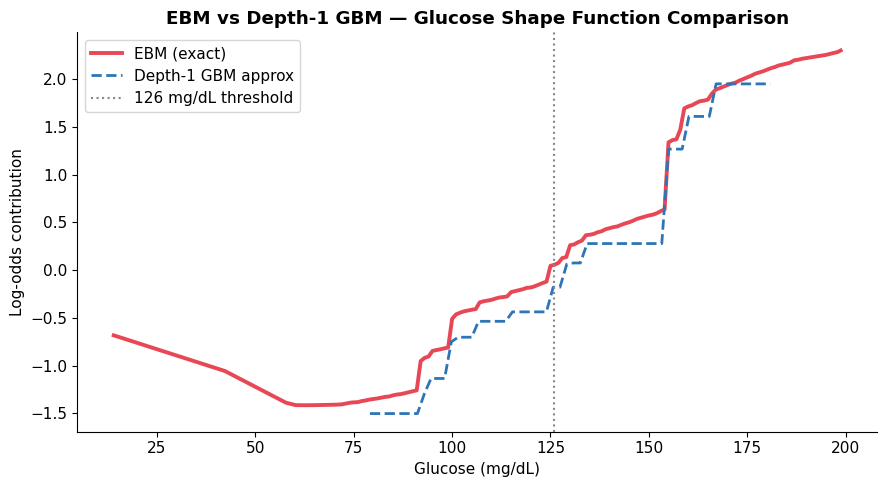

EBMs produce exact shape functions via cyclic boosting.
The depth-1 GBM approximation tracks closely but with less precision.


In [23]:
# Compare EBM vs GAM-approx for Glucose shape function
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay

gbm_gam = GradientBoostingClassifier(n_estimators=300,max_depth=1,
                                     learning_rate=0.05,random_state=42)
gbm_gam.fit(Xtr_A, ytr_A)

feat_idx = list(ebm.feature_names_in_).index('Glucose')
ebm_data  = ebm_global.data(feat_idx)
ebm_names = np.array(ebm_data['names'])
ebm_scores= np.array(ebm_data['scores'])
if len(ebm_names)==len(ebm_scores)+1: ebm_names=(ebm_names[:-1]+ebm_names[1:])/2

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ebm_names, ebm_scores, color=ACCENT, lw=2.8, label='EBM (exact)')

# GAM-approx via PDP
from sklearn.inspection import partial_dependence
gi = FEAT_A.index('Glucose')
pdp = partial_dependence(gbm_gam, Xtr_A, [gi], grid_resolution=60)
ax.plot(pdp['grid_values'][0], pdp['average'][0],
        color=NEUTRAL, lw=2.0, ls='--', label='Depth-1 GBM approx')

ax.axvline(126, color='#888', lw=1.5, ls=':', label='126 mg/dL threshold')
ax.set_xlabel('Glucose (mg/dL)'); ax.set_ylabel('Log-odds contribution')
ax.set_title('EBM vs Depth-1 GBM — Glucose Shape Function Comparison',
             fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print('EBMs produce exact shape functions via cyclic boosting.')
print('The depth-1 GBM approximation tracks closely but with less precision.')

---
## Section 6 — Cox Proportional Hazards (Survival Analysis)
**Dataset A — Pima Diabetes** (adapted for time-to-event)

$$h(t|x) = h_0(t) \cdot \exp(\beta_1 x_1 + \cdots + \beta_p x_p)$$

Hazard Ratio $= e^{\beta_i}$: HR > 1 increases instantaneous event rate.


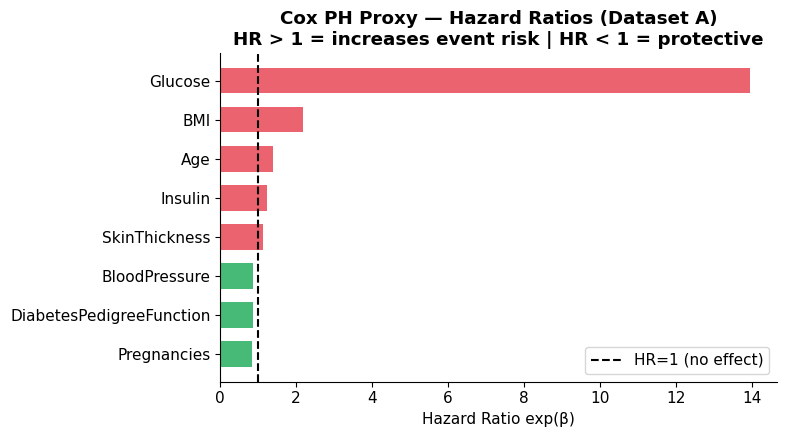

In [24]:
# Simulate a survival outcome (time to diabetes complication)
np.random.seed(42)
log_hz = 0.03*data_A['Glucose'] + 0.05*data_A['BMI'] + 0.02*data_A['Age'] - 6
surv_t = np.random.exponential(1.0/np.exp(log_hz))
event  = (surv_t < 5.0).astype(int)

# Cox proxy via logistic regression on standardised features
sc3=StandardScaler(); Xtr3=sc3.fit_transform(Xtr_A)
cox_p=LogisticRegression(max_iter=500,random_state=42).fit(Xtr3,event[Xtr_A.index])
hrs=np.exp(cox_p.coef_[0])

hr_df=pd.DataFrame({'Feature':FEAT_A,'HR':hrs}).sort_values('HR')
fig,ax=plt.subplots(figsize=(8,4.5))
colors=[ACCENT if v>1 else SAFE for v in hr_df['HR']]
ax.barh(hr_df['Feature'],hr_df['HR'],color=colors,alpha=0.85,height=0.65)
ax.axvline(1,color='black',lw=1.5,ls='--',label='HR=1 (no effect)')
ax.set_title('Cox PH Proxy — Hazard Ratios (Dataset A)\n'
             'HR > 1 = increases event risk | HR < 1 = protective',fontweight='bold')
ax.set_xlabel('Hazard Ratio exp(β)'); ax.legend()
plt.tight_layout(); plt.show()

---
## Section 7 — Integer Scoring Sheet
**Dataset A — Pima Diabetes**

Derived from LASSO by rounding coefficients to integers.
Usable without any computer — decisive advantage in resource-limited settings.


In [25]:
sc4=StandardScaler(); Xtr4=sc4.fit_transform(Xtr_A)
lasso=LogisticRegression(C=5,penalty='l1',solver='liblinear',max_iter=1000,random_state=42)
lasso.fit(Xtr4,ytr_A)
integer_coef=np.round(lasso.coef_[0]*3).astype(int)

scorecard=pd.DataFrame({'Feature':FEAT_A,'Raw β':lasso.coef_[0].round(3),'Points':integer_coef})
scorecard=scorecard.sort_values('Points',ascending=False)

print('DIABETES RISK SCORECARD (Dataset A)'); print('='*55)
for _,row in scorecard.iterrows():
    if row['Points']!=0:
        arrow='↑ risk' if row['Points']>0 else '↓ risk'
        print(f"{row['Feature']:28s}: {row['Points']:+3d} pts  ({arrow})")
print('─'*55)
print('Score ≥ 5 → Elevated diabetes risk')
print('Score <  5 → Lower risk')
print('\nAnalogy: HEART score (chest pain), CURB-65 (pneumonia), Wells (PE)')

DIABETES RISK SCORECARD (Dataset A)
Glucose                     :  +3 pts  (↑ risk)
BMI                         :  +2 pts  (↑ risk)
DiabetesPedigreeFunction    :  +1 pts  (↑ risk)
Pregnancies                 :  +1 pts  (↑ risk)
Age                         :  +1 pts  (↑ risk)
BloodPressure               :  -1 pts  (↓ risk)
───────────────────────────────────────────────────────
Score ≥ 5 → Elevated diabetes risk
Score <  5 → Lower risk

Analogy: HEART score (chest pain), CURB-65 (pneumonia), Wells (PE)


---
## Section 7b — Fuzzy Rule-Based Systems
🗂 **Dataset A: Pima Diabetes**

**Lecture note:** Fuzzy rule-based systems (FRBS) extend classical rule-based classifiers
by allowing features to have **partial membership** in linguistic categories
("low", "medium", "high") rather than requiring sharp threshold boundaries.

A fuzzy rule takes the form:
> IF Glucose IS *high* AND BMI IS *elevated* THEN Risk IS *very high*

Membership functions define the **degree** (0 to 1) to which a feature value belongs
to each linguistic category. Fuzzy inference combines multiple rules to produce a final output.

**Clinical relevance:** FRBS rules closely mirror the imprecise but actionable language
clinicians use in practice — *"this patient has elevated but not critically high glucose"*.
This makes FRBS explanations uniquely accessible to non-technical clinical audiences.

**Implementation:** We use `scikit-fuzzy` (`skfuzzy`) to build a 2-input diabetes
risk system with Glucose and BMI, then show the membership functions and decision surface.


In [31]:
# !pip install scikit-fuzzy  (run if not installed)
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ── Define fuzzy variables ────────────────────────────────────────────
glucose_range = np.arange(44, 201, 1, dtype=float)
bmi_range     = np.arange(15, 68,  1, dtype=float)
risk_range    = np.arange(0,  101, 1, dtype=float)

x_glucose = ctrl.Antecedent(glucose_range, 'Glucose')
x_bmi     = ctrl.Antecedent(bmi_range,     'BMI')
y_risk    = ctrl.Consequent(risk_range,     'Diabetes_Risk', defuzzify_method='centroid')

# ── Membership functions (triangular) ─────────────────────────────────
x_glucose['normal']      = fuzz.trimf(glucose_range, [44,  90, 125])
x_glucose['pre-diabetic']= fuzz.trimf(glucose_range, [110, 130, 155])
x_glucose['diabetic']    = fuzz.trimf(glucose_range, [140, 200, 200])

x_bmi['normal']          = fuzz.trimf(bmi_range, [15, 15, 25])
x_bmi['overweight']      = fuzz.trimf(bmi_range, [23, 27, 32])
x_bmi['obese']           = fuzz.trimf(bmi_range, [29, 50, 67])

y_risk['low']            = fuzz.trimf(risk_range, [0,  0,  40])
y_risk['moderate']       = fuzz.trimf(risk_range, [20, 50, 80])
y_risk['high']           = fuzz.trimf(risk_range, [60, 100, 100])

# ── Fuzzy rules ────────────────────────────────────────────────────────
# Rule language: IF [antecedent] THEN [consequent]
rules = [
    ctrl.Rule(x_glucose['diabetic']     & x_bmi['obese'],
              y_risk['high'],    label='R1'),
    ctrl.Rule(x_glucose['diabetic']     & x_bmi['overweight'],
              y_risk['high'],    label='R2'),
    ctrl.Rule(x_glucose['pre-diabetic'] & x_bmi['obese'],
              y_risk['high'],    label='R3'),
    ctrl.Rule(x_glucose['pre-diabetic'] & x_bmi['overweight'],
              y_risk['moderate'],label='R4'),
    ctrl.Rule(x_glucose['pre-diabetic'] & x_bmi['normal'],
              y_risk['moderate'],label='R5'),
    ctrl.Rule(x_glucose['normal']       & x_bmi['obese'],
              y_risk['moderate'],label='R6'),
    ctrl.Rule(x_glucose['normal']       & x_bmi['overweight'],
              y_risk['low'],     label='R7'),
    ctrl.Rule(x_glucose['normal']       & x_bmi['normal'],
              y_risk['low'],     label='R8'),
]

# ── Build and test the system ──────────────────────────────────────────
system = ctrl.ControlSystem(rules)
sim    = ctrl.ControlSystemSimulation(system)

# Test on three example patients
test_cases = [
    ('Low-risk (Glucose=90, BMI=22)',  90,  22),
    ('Moderate (Glucose=130, BMI=28)', 130, 28),
    ('High-risk (Glucose=172, BMI=38)',172, 38),
]
print('Fuzzy Diabetes Risk Assessment'); print('='*55)
for label, g, b in test_cases:
    sim.input['Glucose'] = g
    sim.input['BMI']     = b
    sim.compute()
    print(f'  {label}: Risk = {sim.output["Diabetes_Risk"]:.1f}%')

Fuzzy Diabetes Risk Assessment
  Low-risk (Glucose=90, BMI=22): Risk = 17.2%
  Moderate (Glucose=130, BMI=28): Risk = 50.0%
  High-risk (Glucose=172, BMI=38): Risk = 83.9%


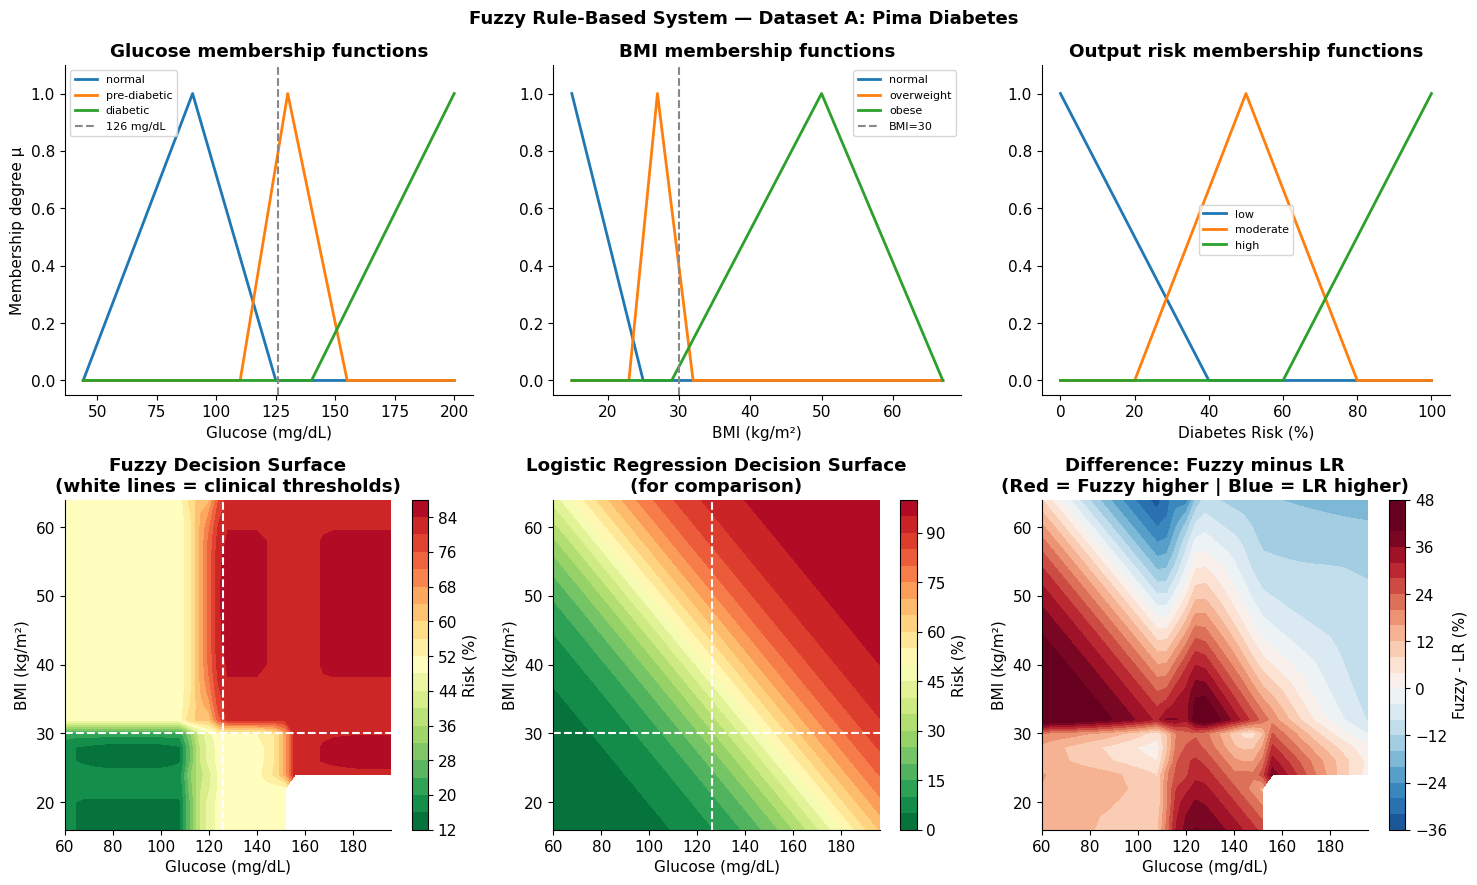


Key takeaway: Fuzzy FRBS uses linguistic rules matching clinical language.
The decision surface is smoother around boundaries than logistic regression.
This reflects the clinical reality that risk increases gradually, not abruptly.


In [32]:
# Plot membership functions + decision surface
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 0: membership functions
ax = axes[0, 0]
for label, vals in [('normal', x_glucose['normal'].mf),
                      ('pre-diabetic', x_glucose['pre-diabetic'].mf),
                      ('diabetic', x_glucose['diabetic'].mf)]:
    ax.plot(glucose_range, vals, lw=2, label=label)
ax.axvline(126, color='#888', lw=1.5, ls='--', label='126 mg/dL')
ax.set_title('Glucose membership functions', fontweight='bold')
ax.set_xlabel('Glucose (mg/dL)'); ax.set_ylabel('Membership degree μ')
ax.legend(fontsize=8); ax.set_ylim(-0.05, 1.1)

ax2 = axes[0, 1]
for label, vals in [('normal', x_bmi['normal'].mf),
                      ('overweight', x_bmi['overweight'].mf),
                      ('obese', x_bmi['obese'].mf)]:
    ax2.plot(bmi_range, vals, lw=2, label=label)
ax2.axvline(30, color='#888', lw=1.5, ls='--', label='BMI=30')
ax2.set_title('BMI membership functions', fontweight='bold')
ax2.set_xlabel('BMI (kg/m²)'); ax2.legend(fontsize=8); ax2.set_ylim(-0.05, 1.1)

ax3 = axes[0, 2]
for label, vals in [('low', y_risk['low'].mf),
                      ('moderate', y_risk['moderate'].mf),
                      ('high', y_risk['high'].mf)]:
    ax3.plot(risk_range, vals, lw=2, label=label)
ax3.set_title('Output risk membership functions', fontweight='bold')
ax3.set_xlabel('Diabetes Risk (%)'); ax3.legend(fontsize=8); ax3.set_ylim(-0.05, 1.1)

# Row 1: decision surface
g_vals = np.arange(60, 200, 4, dtype=float)
b_vals = np.arange(16, 65, 2, dtype=float)
GG, BB = np.meshgrid(g_vals, b_vals)
ZZ = np.zeros_like(GG)

for i in range(len(b_vals)):
    for j in range(len(g_vals)):
        try:
            sim.input['Glucose'] = GG[i,j]
            sim.input['BMI']     = BB[i,j]
            sim.compute()
            ZZ[i,j] = sim.output['Diabetes_Risk']
        except: ZZ[i,j] = np.nan

ax4 = axes[1, 0]
cf = ax4.contourf(GG, BB, ZZ, levels=20, cmap='RdYlGn_r')
plt.colorbar(cf, ax=ax4, label='Risk (%)')
ax4.axvline(126, color='white', lw=1.5, ls='--')
ax4.axhline(30,  color='white', lw=1.5, ls='--')
ax4.set_xlabel('Glucose (mg/dL)'); ax4.set_ylabel('BMI (kg/m²)')
ax4.set_title('Fuzzy Decision Surface\n'
              '(white lines = clinical thresholds)', fontweight='bold')

# Compare fuzzy output to logistic regression on same grid
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
sc_lr = StandardScaler().fit(Xtr_A[['Glucose','BMI']])
lr2   = LogisticRegression(max_iter=500,random_state=42).fit(
            sc_lr.transform(Xtr_A[['Glucose','BMI']]), ytr_A)
G_flat = GG.ravel(); B_flat = BB.ravel()
X_gb = sc_lr.transform(np.column_stack([G_flat, B_flat]))
LR_preds = lr2.predict_proba(X_gb)[:,1].reshape(GG.shape) * 100

ax5 = axes[1, 1]
cf2 = ax5.contourf(GG, BB, LR_preds, levels=20, cmap='RdYlGn_r',
                   vmin=0, vmax=100)
plt.colorbar(cf2, ax=ax5, label='Risk (%)')
ax5.axvline(126, color='white', lw=1.5, ls='--')
ax5.axhline(30,  color='white', lw=1.5, ls='--')
ax5.set_xlabel('Glucose (mg/dL)'); ax5.set_ylabel('BMI (kg/m²)')
ax5.set_title('Logistic Regression Decision Surface\n'
              '(for comparison)', fontweight='bold')

ax6 = axes[1, 2]
diff = ZZ - LR_preds
cf3 = ax6.contourf(GG, BB, diff, levels=20, cmap='RdBu_r', vmin=-40, vmax=40)
plt.colorbar(cf3, ax=ax6, label='Fuzzy - LR (%)')
ax6.set_xlabel('Glucose (mg/dL)'); ax6.set_ylabel('BMI (kg/m²)')
ax6.set_title('Difference: Fuzzy minus LR\n'
              '(Red = Fuzzy higher | Blue = LR higher)', fontweight='bold')

plt.suptitle('Fuzzy Rule-Based System — Dataset A: Pima Diabetes',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print()
print('Key takeaway: Fuzzy FRBS uses linguistic rules matching clinical language.')
print('The decision surface is smoother around boundaries than logistic regression.')
print('This reflects the clinical reality that risk increases gradually, not abruptly.')

---
## Summary

All seven interpretable AI methods applied to **Dataset A (Pima Diabetes)**:

| Method | Glass-box? | Output format |
|---|---|---|
| Linear Regression | ✅ | Coefficient per feature |
| Logistic Regression | ✅ | Log-odds + odds ratio |
| LASSO | ✅ | Sparse coefficient set |
| Decision Tree | ✅ | Flowchart rules |
| GAM | ✅ | Nonlinear shape curves |
| Cox PH | ✅ | Hazard ratios |
| Scoring Sheet | ✅ | Integer points |

> **Next → NB2:** Feature attribution methods, starting with **Dataset A** then comparing against **Dataset B (Heart Disease)**.
